In [21]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

In [22]:
def add_gaussian_noise(image, mean=0, sigma=25):
    """Добавление шума Гаусса"""
    gaussian_noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = image.astype(np.float32) + gaussian_noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def add_constant_noise(image, value=100, p=0.15):
    """Добавление импульсного шума (Salt & Pepper / Constant)"""
    noisy_image = image.copy()
    mask = np.random.rand(*image.shape) < p
    noisy_image[mask] = np.clip(noisy_image[mask].astype(np.int16) + value, 0, 255).astype(np.uint8)
    return noisy_image

def calculate_metrics(orig, filtered):
    """Расчет SSIM и RMSE"""
    score_ssim, _ = ssim(orig, filtered, full=True)
    mse = np.mean((orig.astype(np.float32) - filtered.astype(np.float32)) ** 2)
    rmse = np.sqrt(mse)
    return round(score_ssim, 2), round(rmse, 2)

In [ ]:
image = cv2.imread('img.jpg')

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gaussian_noisy = add_gaussian_noise(image_gray, mean=0, sigma=30)
constant_noisy = add_constant_noise(image_gray, value=100, p=0.15)

In [ ]:
tests_config = [
    ("Salt & Pepper", "Median Filter", "kernel=3", lambda img: cv2.medianBlur(img, 3), constant_noisy),
    ("Salt & Pepper", "Median Filter", "kernel=5", lambda img: cv2.medianBlur(img, 5), constant_noisy),
    ("Gaussian", "Median Filter", "kernel=3", lambda img: cv2.medianBlur(img, 3), gaussian_noisy),
    ("Gaussian", "Gaussian Blur", "kernel=(5, 5)", lambda img: cv2.GaussianBlur(img, (5, 5), 0), gaussian_noisy),
    ("Gaussian", "Gaussian Blur", "kernel=(9, 9)", lambda img: cv2.GaussianBlur(img, (9, 9), 0), gaussian_noisy),
    ("Salt & Pepper", "Gaussian Blur", "kernel=(5, 5)", lambda img: cv2.GaussianBlur(img, (5, 5), 0), constant_noisy),
    ("Gaussian", "Bilateral Filter", "d=9, sColor=75, sSpace=75", lambda img: cv2.bilateralFilter(img, 9, 75, 75), gaussian_noisy),
    ("Gaussian", "Bilateral Filter", "d=15, sColor=150, sSpace=150", lambda img: cv2.bilateralFilter(img, 15, 150, 150), gaussian_noisy),
    ("Salt & Pepper", "Bilateral Filter", "d=9, sColor=75, sSpace=75", lambda img: cv2.bilateralFilter(img, 9, 75, 75), constant_noisy),
    ("Gaussian", "Non-Local Means", "h=60, template=7, search=21", lambda img: cv2.fastNlMeansDenoising(img, None, 60, 7, 21), gaussian_noisy),
    ("Gaussian", "Non-Local Means", "h=80, template=7, search=21", lambda img: cv2.fastNlMeansDenoising(img, None, 80, 7, 21), gaussian_noisy),
    ("Salt & Pepper", "Non-Local Means", "h=60, template=7, search=21", lambda img: cv2.fastNlMeansDenoising(img, None, 60, 7, 21), constant_noisy),
]

table_data = []
processed_images = []

for noise_type, filter_name, params, func, noisy_img in tests_config:
    filtered_img = func(noisy_img)
    ssim_val, rmse_val = calculate_metrics(image_gray, filtered_img)
    
    table_data.append({
        "Noise Type": noise_type,
        "Filter": filter_name,
        "Parameters": params,
        "SSIM": ssim_val,
        "RMSE": rmse_val
    })
    
    label = f"{filter_name}\n({params})"
    processed_images.append((label, filtered_img, rmse_val))

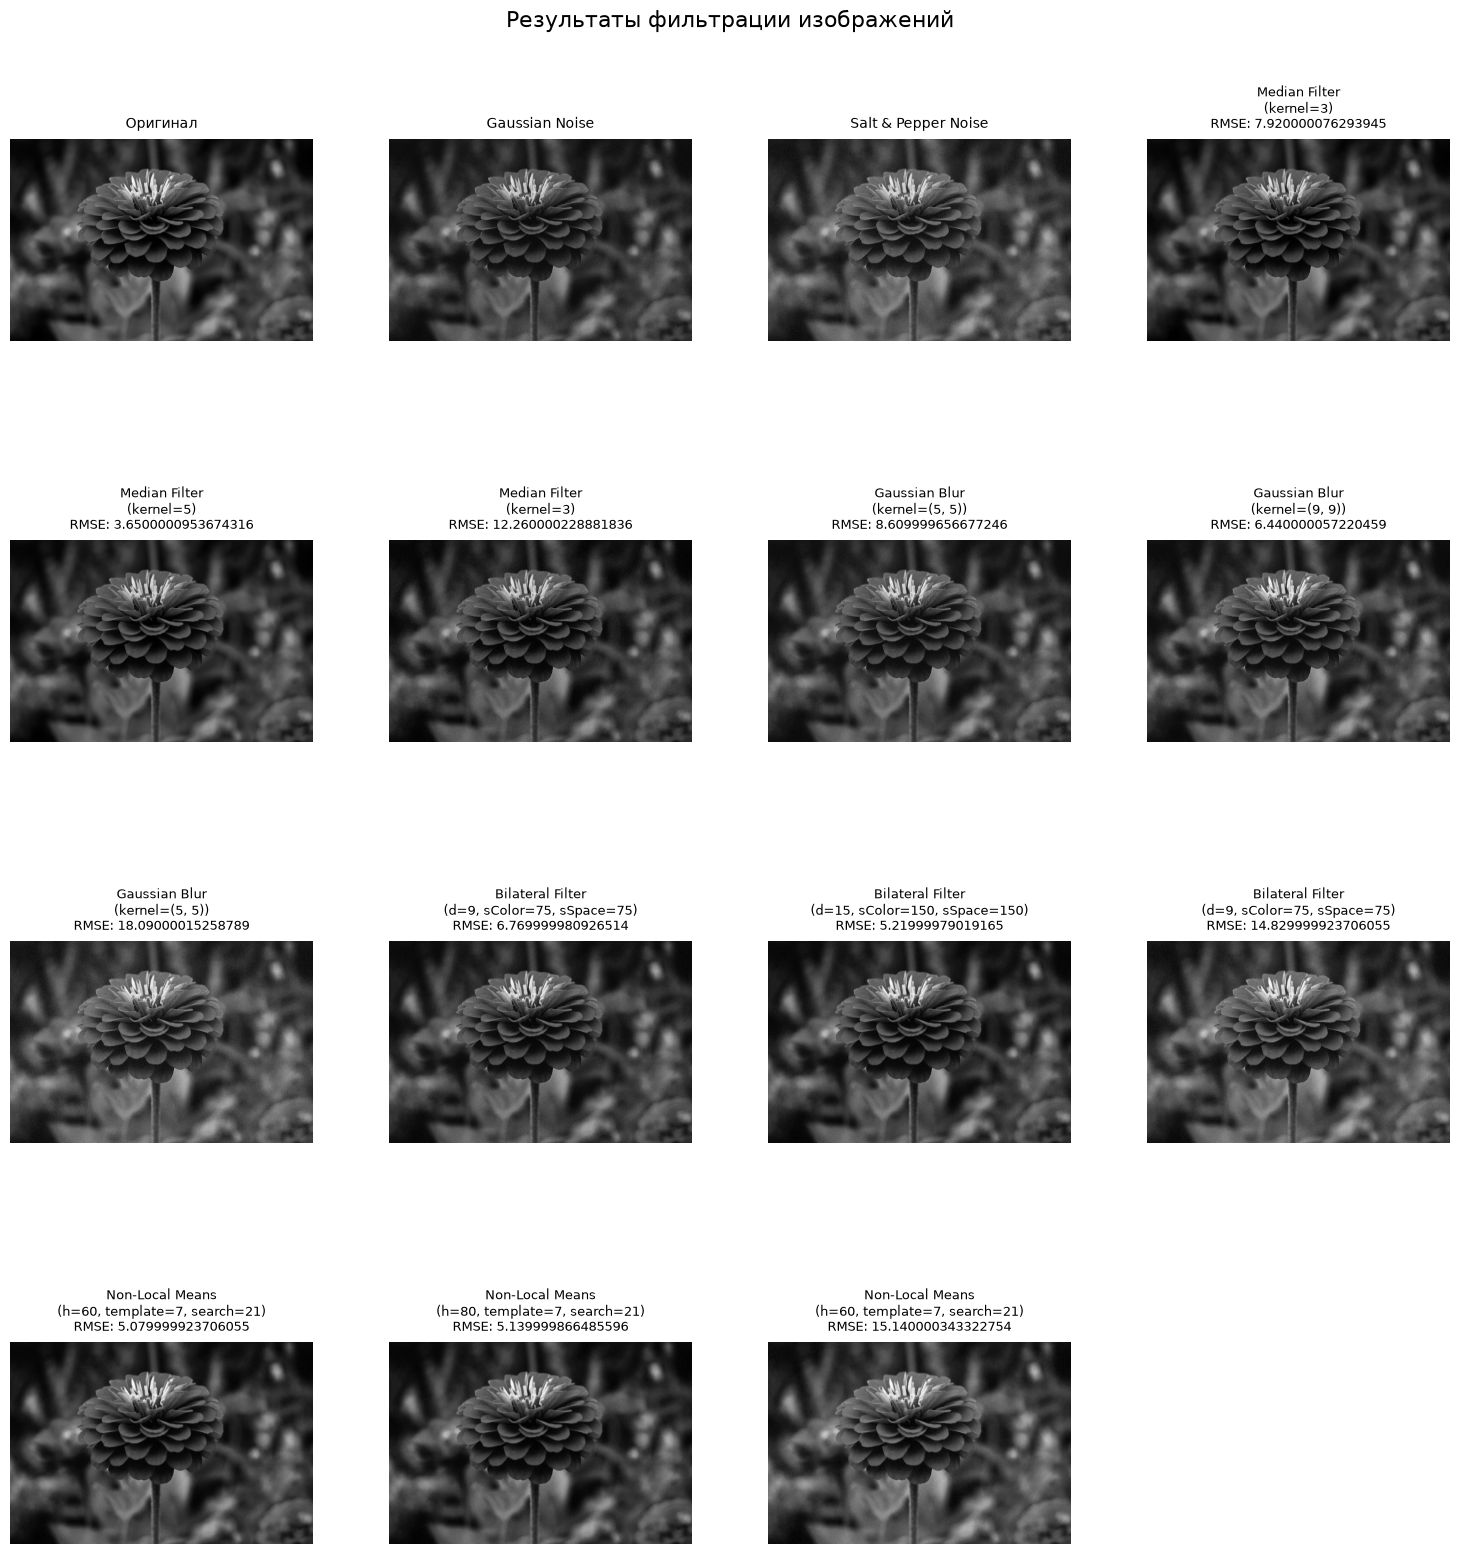

In [ ]:
total_imgs = len(processed_images) + 3  
cols = 4
rows = (total_imgs + cols - 1) // cols

fig = plt.figure(figsize=(16, 4.2 * rows))
fig.suptitle("Результаты фильтрации изображений", fontsize=16, y=0.98)

ax = plt.subplot(rows, cols, 1)
ax.imshow(image_gray, cmap='gray')
ax.set_title("Оригинал", fontsize=10, pad=8)
ax.axis('off')

ax = plt.subplot(rows, cols, 2)
ax.imshow(gaussian_noisy, cmap='gray')
ax.set_title("Gaussian Noise", fontsize=10, pad=8)
ax.axis('off')

ax = plt.subplot(rows, cols, 3)
ax.imshow(constant_noisy, cmap='gray')
ax.set_title("Salt & Pepper Noise", fontsize=10, pad=8)
ax.axis('off')

for idx, (label, img_res, rmse_val) in enumerate(processed_images, start=4):
    ax = plt.subplot(rows, cols, idx)
    ax.imshow(img_res, cmap='gray')
    ax.set_title(f"{label}\nRMSE: {rmse_val}", fontsize=9, pad=8)
    ax.axis('off')

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.92, hspace=0.55, wspace=0.25)
plt.show()

In [ ]:
df = pd.DataFrame(table_data)

display(df)

print("# The best result for Gaussian noise filtering is Non-Local Means")
print("# The best result for constant noise filtering is Median Filter")

,Noise Type,Filter,Parameters,SSIM,RMSE
0,Salt & Pepper,Median Filter,kernel=3,0.79,7.92
1,Salt & Pepper,Median Filter,kernel=5,0.85,3.65
2,Gaussian,Median Filter,kernel=3,0.35,12.26
3,Gaussian,Gaussian Blur,"kernel=(5, 5)",0.55,8.61
4,Gaussian,Gaussian Blur,"kernel=(9, 9)",0.72,6.44
5,Salt & Pepper,Gaussian Blur,"kernel=(5, 5)",0.43,18.09
6,Gaussian,Bilateral Filter,"d=9, sColor=75, sSpace=75",0.67,6.77
7,Gaussian,Bilateral Filter,"d=15, sColor=150, sSpace=150",0.81,5.22
8,Salt & Pepper,Bilateral Filter,"d=9, sColor=75, sSpace=75",0.41,14.83
9,Gaussian,Non-Local Means,"h=60, template=7, search=21",0.82,5.08


# The best result for Gaussian noise filtering is Non-Local Means
# The best result for constant noise filtering is Median Filter
